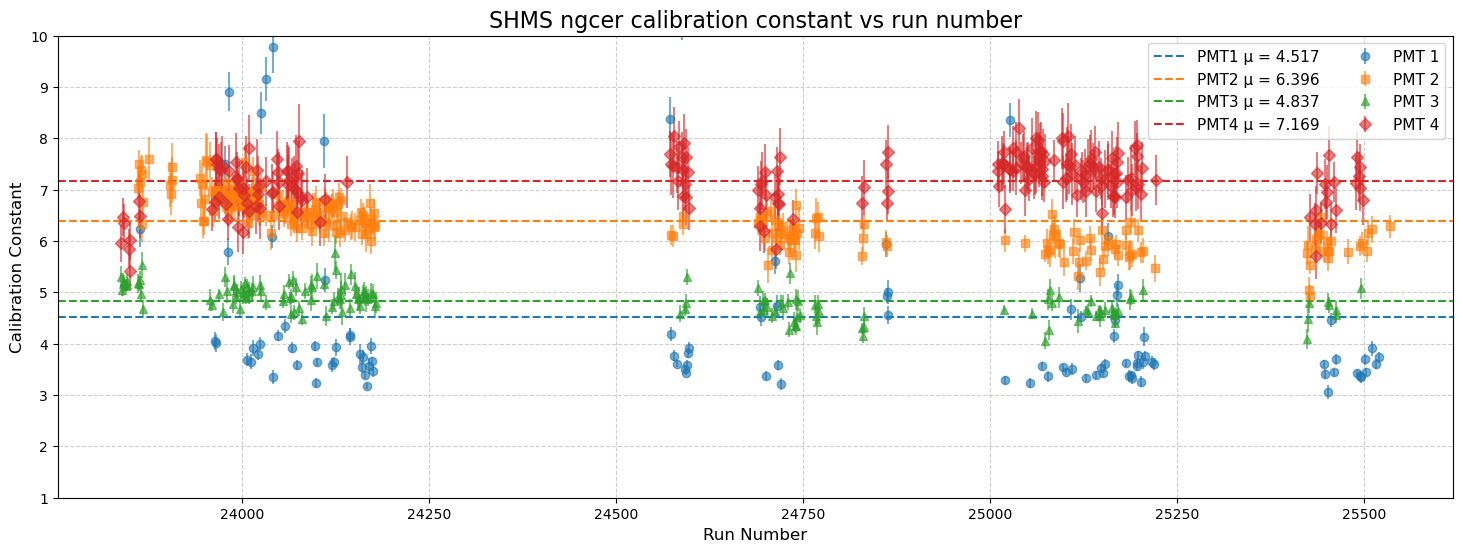

In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import matplotlib.cm as cm
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns




# Load data

bigtable = pd.read_csv('../rsidis_bigtable_pass0.csv')
bigtable["run"] = bigtable["run"].astype(int)
mask = ((bigtable["hms_p"] < 0))
data = pd.read_csv('pngcer_calibration_summary.csv')

# PMT1

pmt1 = data[((data['nevents']>1000) & (data['pmt']==1) & (df["calibration_error"] < 2) & (df["chi2_ndf"]< 5))]
pmt1_mean = pmt1["calibration_constant"].mean()
pmt1_std = pmt1["calibration_constant"].std()
merged_pmt1 = pd.merge(bigtable, pmt1, on="run", how="inner", suffixes=("", "_fit"))

# PMT2
pmt2 = data[((data['nevents']>1000) & (data['pmt']==2) & (df["calibration_error"] < 2) & (df["chi2_ndf"]< 5))]
pmt2_mean = pmt2["calibration_constant"].mean()
pmt2_std = pmt2["calibration_constant"].std()
merged_pmt2 = pd.merge(bigtable, pmt2, on="run", how="inner", suffixes=("", "_fit"))

# PMT3

pmt3 = data[((data['nevents']>1000) & (data['pmt']==3) & (df["calibration_error"] < 2) & (df["chi2_ndf"]< 5))]
pmt3_mean = pmt3["calibration_constant"].mean()
pmt3_std = pmt3["calibration_constant"].std()
merged_pmt3 = pd.merge(bigtable, pmt3, on="run", how="inner", suffixes=("", "_fit"))

# PMT4

pmt4 = data[((data['nevents']>1000) & (data['pmt']==4) & (df["calibration_error"] < 2) & (df["chi2_ndf"]< 5))]
pmt4_mean = pmt4["calibration_constant"].mean()
pmt4_std = pmt4["calibration_constant"].std()
merged_pmt4 = pd.merge(bigtable, pmt4, on="run", how="inner", suffixes=("", "_fit"))



plt.figure(figsize=(18, 6))
plt.errorbar(merged_pmt1["run"], merged_pmt1["calibration_constant"], yerr=merged_pmt1["calibration_error"], fmt='o', color=plt.colormaps["tab10"](0), label='PMT 1', alpha=0.6)
plt.errorbar(merged_pmt2["run"], merged_pmt2["calibration_constant"], yerr=merged_pmt2["calibration_error"], fmt='s', color=plt.colormaps["tab10"](1), label='PMT 2', alpha=0.6)
plt.errorbar(merged_pmt3["run"], merged_pmt3["calibration_constant"], yerr=merged_pmt3["calibration_error"], fmt='^', color=plt.colormaps["tab10"](2), label='PMT 3', alpha=0.6)
plt.errorbar(merged_pmt4["run"], merged_pmt4["calibration_constant"], yerr=merged_pmt4["calibration_error"], fmt='D', color=plt.colormaps["tab10"](3), label='PMT 4', alpha=0.6)
plt.axhline(pmt1_mean, color=plt.colormaps["tab10"](0), linestyle='--', label=f'PMT1 µ = {pmt1_mean:.3f}')
plt.axhline(pmt2_mean, color=plt.colormaps["tab10"](1), linestyle='--', label=f'PMT2 µ = {pmt2_mean:.3f}')    
plt.axhline(pmt3_mean, color=plt.colormaps["tab10"](2), linestyle='--', label=f'PMT3 µ = {pmt3_mean:.3f}')
plt.axhline(pmt4_mean, color=plt.colormaps["tab10"](3), linestyle='--', label=f'PMT4 µ = {pmt4_mean:.3f}')
plt.xlabel("Run Number", fontsize=12)
plt.ylabel("Calibration Constant", fontsize=12)
plt.title("SHMS ngcer calibration constant vs run number", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(1,10)
plt.legend(frameon=True, ncol=2, fontsize=11)
plt.show()                                                                                                                                                                                                                                                    

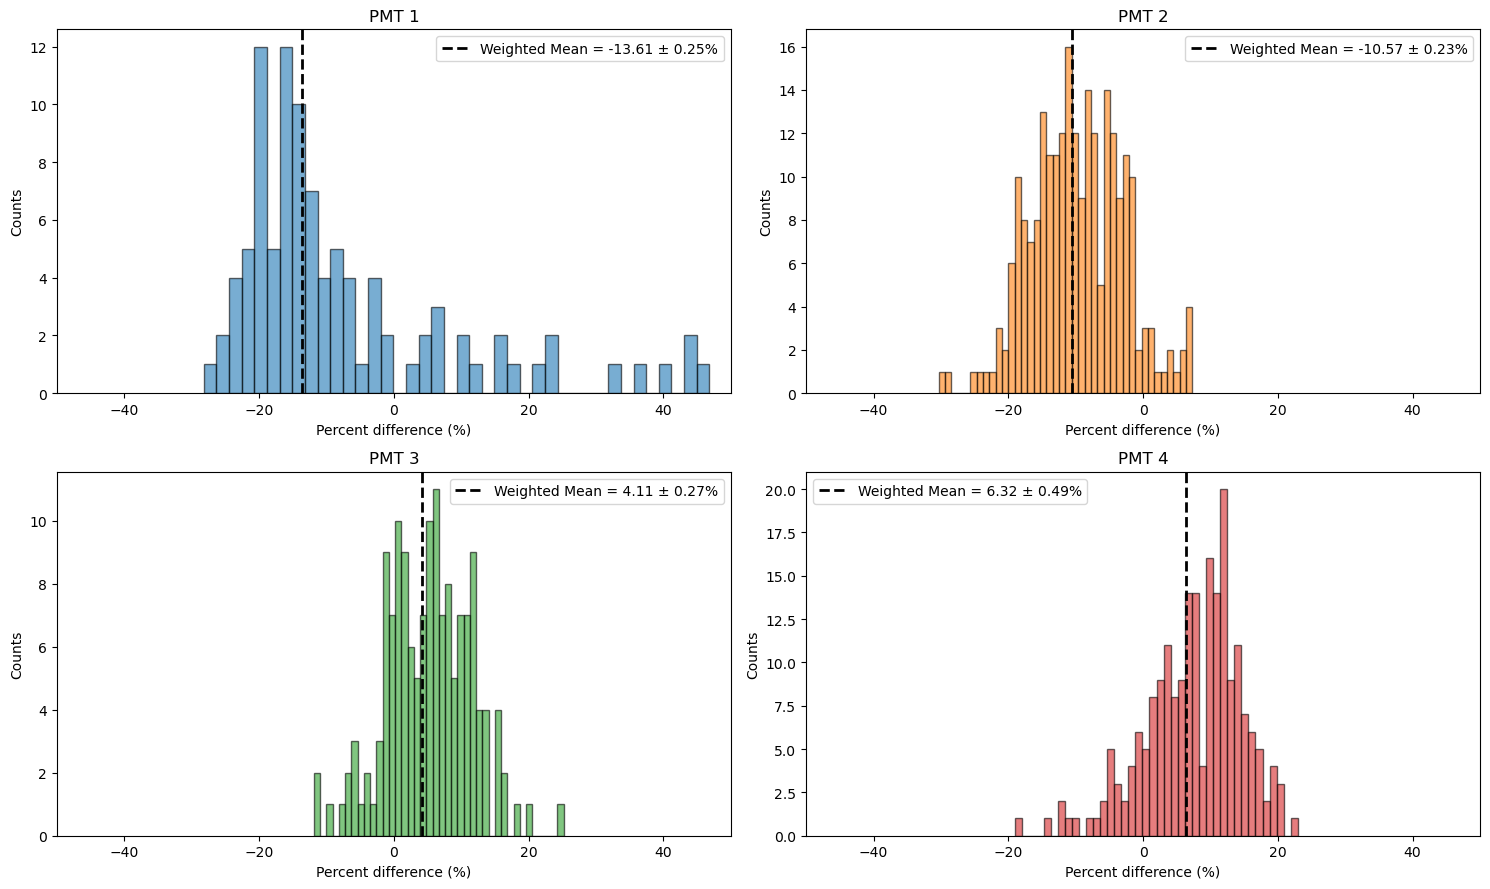

In [197]:


df = pd.read_csv("pngcer_calibration_summary.csv")

nominal = {
    1: 4.25196,
    2: 7.08463,
    3: 4.60135,
    4: 6.67603
}


mask = ((df["nevents"]>1000) & (df["calibration_error"] < 2) & (df["chi2_ndf"]< 5))

# df["percent_diff"] = 100 * (df["calibration_constant"][mask] - df["pmt"][mask].map(nominal)) / df["pmt"][mask].map(nominal)

# for pmt in [1,2,3,4]:
#     plt.figure(figsize=(8,5))
#     data = df[df["pmt"] == pmt]["percent_diff"][np.abs(df["percent_diff"]) < 50]
#     plt.hist(data, bins=50, edgecolor='black')
#     plt.xlim(-50, 50)
#     plt.xlabel("Percent difference (%)")
#     plt.ylabel("Counts")
#     plt.title(f"PMT {pmt} percent difference from nominal")
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.savefig(f"pmt{pmt}_percent_diff_hist.png", dpi=200)
#     plt.show()

def plot_4panel_percent_diff(df):

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes = axes.flatten()

    for pmt in [1, 2, 3, 4]:
        ax = axes[pmt - 1]
        dfp = df[(df["pmt"] == pmt) & mask].copy()

        if dfp.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=14)
            ax.set_title(f"PMT{pmt}")
            continue

        # Compute percent difference
        nominal_value = nominal[pmt]
        dfp["percent_diff"] = 100 * (dfp["calibration_constant"] - nominal_value) / nominal_value
        dfp["percent_err"] = 100 * dfp["calibration_error"] / nominal_value

        # Weighted mean and RMS
        w = 1 / dfp["percent_err"]**2
        w_mean = np.sum(w * dfp["percent_diff"]) / np.sum(w)
        w_err = np.sqrt(1 / np.sum(w))

        # Weighted RMS (std deviation)
        w_rms = np.sqrt(np.sum(w * (dfp["percent_diff"] - w_mean) ** 2) / np.sum(w))

        data = dfp

        # Plot histogram
        ax.hist(dfp["percent_diff"][np.abs(dfp["percent_diff"]) < 50], bins=40, alpha=0.6, color=plt.colormaps["tab10"](pmt-1), edgecolor="black")
        ax.axvline(w_mean, color='k', linestyle='--', linewidth=2, label=f'Weighted Mean = {w_mean:.2f} ± {w_err:.2f}%')
        # ax.axvline(w_mean + w_rms, color='g', linestyle='--', label=f'Weighted RMS = {w_rms:.2f}%')
        # ax.axvline(w_mean - w_rms, color='g', linestyle='--')
        ax.set_xlim(-50, 50)
        ax.legend()
        ax.set_title(f"PMT {pmt}")
        ax.set_xlabel("Percent difference (%)")
        ax.set_ylabel("Counts")

    plt.tight_layout()
    plt.show()

data = pd.read_csv('pngcer_calibration_summary.csv')
plot_4panel_percent_diff(data)
